In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import pyodbc

In [2]:
# Connect to SQL Server and load data
connection = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=DILLIBABU\\SQLEXPRESS;'
    'DATABASE=CFB;'
    'Trusted_Connection=yes;'
)

query = "SELECT * FROM riser"
df = pd.read_sql(query, connection)

print(df.head())

C:\Users\dilli\AppData\Local\Temp\ipykernel_21176\3810146049.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


   Ug   Gs     z    r/R  Solid_holdup  Particle_velocity  Solid_flux
0   5  100  0.57  0.000         0.007               6.12       77.86
1   5  100  5.84  0.950         0.027              -0.04       -2.05
2   5  100  5.84  0.837         0.032               2.47      138.94
3   5  100  5.84  0.548         0.010               7.17      128.14
4   5  100  7.78  0.000         0.010               7.81      139.78


In [3]:
# Select input features and output variable
X = df[['Ug', 'Gs', 'z', 'r/R',
        'Particle_velocity',
        'Solid_flux']]

y = df['Solid_holdup']

In [4]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [5]:
# Standardize feature values
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Convert 2D data into 3D format required by LSTM
X_train = X_train.reshape(
    (X_train.shape[0], 1, X_train.shape[1])
)

X_test = X_test.reshape(
    (X_test.shape[0], 1, X_test.shape[1])
)

print(X_train.shape)
print(X_test.shape)

(960, 1, 6)
(240, 1, 6)


In [7]:
# Create LSTM neural network architecture
model = Sequential()

model.add(
    LSTM(
        64,
        activation='tanh',
        input_shape=(1, X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1))

C:\Users\dilli\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Configure model optimizer, loss function and metrics
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,801 (81.25 KB)

 Trainable params: 20,801 (81.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the LSTM model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0226 - mae: 0.0928 - val_loss: 0.0111 - val_mae: 0.0732
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0064 - mae: 0.0552 - val_loss: 0.0039 - val_mae: 0.0404
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0038 - mae: 0.0384 - val_loss: 0.0031 - val_mae: 0.0315
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0031 - mae: 0.0329 - val_loss: 0.0028 - val_mae: 0.0284
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0029 - mae: 0.0306 - val_loss: 0.0024 - val_mae: 0.0278
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0028 - mae: 0.0301 - val_loss: 0.0022 - val_mae: 0.0265
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - mae: 0.0297 - val_loss: 0.0027 - val_mae: 0.0270
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0025 - mae: 0.0277 - val_loss: 0.0021 - val_mae: 0.0253
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - los

In [10]:
# Predict solid holdup values for test data
y_pred = model.predict(X_test)

y_pred = y_pred.flatten()

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step 


In [11]:
# Evaluate model performance using regression metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 0.015533927561777332
MSE : 0.0011765933610114435
RMSE : 0.03430150668719151
R² Score : 0.9394413832303823


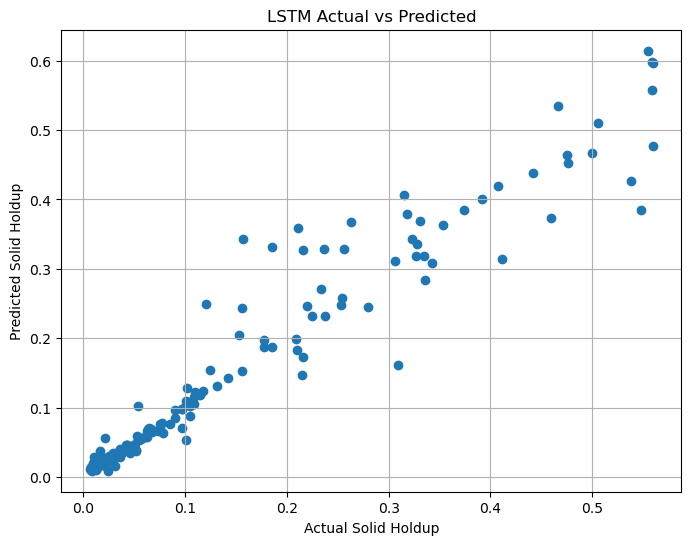

In [12]:
# Visualize actual and predicted values
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Solid Holdup")

plt.ylabel("Predicted Solid Holdup")

plt.title("LSTM Actual vs Predicted")

plt.grid(True)

plt.show()

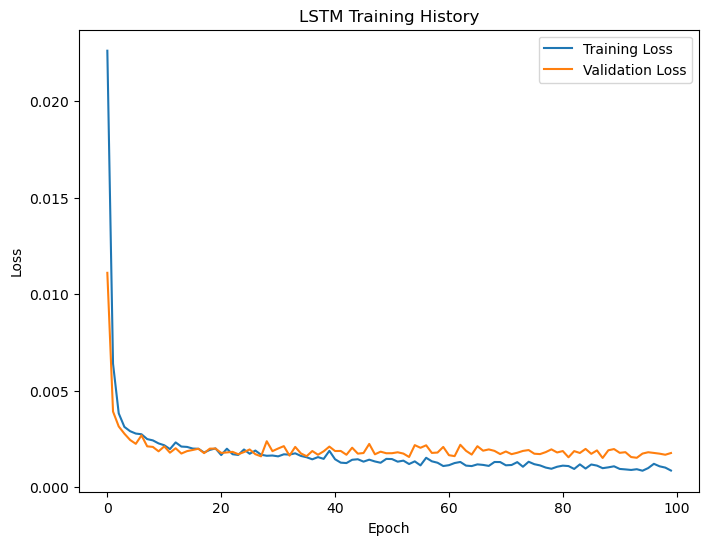

In [13]:
# Plot training and validation loss curves
plt.figure(figsize=(8,6))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("LSTM Training History")

plt.legend()

plt.show()

In [14]:
# Save trained LSTM model
model.save("solid_holdup_lstm_model.keras")

print("LSTM Model Saved Successfully")

LSTM Model Saved Successfully


In [15]:
# Load previously saved LSTM model
loaded_model = tf.keras.models.load_model(
    "solid_holdup_lstm_model.keras"
)

In [16]:
# Predict solid holdup for new input data
new_data = np.array([
    [5, 100, 3, 0.5, 2.5, 250]
])

new_data = scaler.transform(new_data)

new_data = new_data.reshape(
    (new_data.shape[0], 1, new_data.shape[1])
)

prediction = loaded_model.predict(new_data)

print("Predicted Solid Holdup:", prediction[0][0])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
Predicted Solid Holdup: 0.028048642
